git status
git add scripts/build_metrics_comparison.py
git add -f outputs/metrics/*.csv
git commit -m "Build metrics comparison dataset"
git push

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
COMPARISON_FILE = Path("../outputs/metrics/euro_2024_final_centre_backs_comparison.csv")

comparison_df = pd.read_csv(COMPARISON_FILE)

comparison_df

,player,team,position,competition,season,match,match_date,competition_stage,total_passes,completed_passes,incomplete_passes,completion_rate,forward_passes,forward_pass_share,long_passes,long_pass_share,average_pass_length,source_file
0,John Stones,England,Right Center Back,UEFA Euro,2024,Spain 2 - 1 England,2024-07-14,Final,35,30,5,0.857143,23,0.657143,11,0.314286,27.687211,john_stones_metrics.csv
1,Marc Guehi,England,Left Center Back,UEFA Euro,2024,Spain 2 - 1 England,2024-07-14,Final,26,23,3,0.884615,17,0.653846,4,0.153846,18.888058,marc_guehi_metrics.csv
2,Aymeric Laporte,Spain,Left Center Back,UEFA Euro,2024,Spain 2 - 1 England,2024-07-14,Final,83,80,3,0.963855,50,0.602410,19,0.228916,22.301625,aymeric_laporte_metrics.csv
3,José Ignacio Fernández Iglesias,Spain,Right Center Back,UEFA Euro,2024,Spain 2 - 1 England,2024-07-14,Final,3,3,0,1.000000,3,1.000000,0,0.000000,18.092738,jose_ignacio_fernandez_iglesias_metrics.csv
4,Robin Aime Robert Le Normand,Spain,Right Center Back,UEFA Euro,2024,Spain 2 - 1 England,2024-07-14,Final,84,80,4,0.952381,65,0.773810,11,0.130952,21.857340,robin_aime_robert_le_normand_metrics.csv


In [3]:
comparison_df.columns.tolist()

['player',
 'team',
 'position',
 'competition',
 'season',
 'match',
 'match_date',
 'competition_stage',
 'total_passes',
 'completed_passes',
 'incomplete_passes',
 'completion_rate',
 'forward_passes',
 'forward_pass_share',
 'long_passes',
 'long_pass_share',
 'average_pass_length',
 'source_file']

In [12]:
comparison_df["completion_rate_pct"] = comparison_df["completion_rate"] * 100
comparison_df["forward_pass_share_pct"] = comparison_df["forward_pass_share"] * 100
comparison_df["long_pass_share_pct"] = comparison_df["long_pass_share"] * 100

In [13]:
comparison_df[
    [
        "player",
        "team",
        "position",
        "total_passes",
        "completed_passes",
        "completion_rate_pct",
        "forward_passes",
        "forward_pass_share_pct",
        "long_passes",
        "long_pass_share_pct",
        "average_pass_length"
    ]
]

,player,team,position,total_passes,completed_passes,completion_rate_pct,forward_passes,forward_pass_share_pct,long_passes,long_pass_share_pct,average_pass_length
0,John Stones,England,Right Center Back,35,30,85.714286,23,65.714286,11,31.428571,27.687211
1,Marc Guehi,England,Left Center Back,26,23,88.461538,17,65.384615,4,15.384615,18.888058
2,Aymeric Laporte,Spain,Left Center Back,83,80,96.385542,50,60.240964,19,22.891566,22.301625
3,José Ignacio Fernández Iglesias,Spain,Right Center Back,3,3,100.000000,3,100.000000,0,0.000000,18.092738
4,Robin Aime Robert Le Normand,Spain,Right Center Back,84,80,95.238095,65,77.380952,11,13.095238,21.857340


In [14]:
comparison_table = comparison_df[
    [
        "player",
        "team",
        "position",
        "total_passes",
        "completed_passes",
        "incomplete_passes",
        "completion_rate_pct",
        "forward_passes",
        "forward_pass_share_pct",
        "long_passes",
        "long_pass_share_pct",
        "average_pass_length"
    ]
].copy()

comparison_table = comparison_table.sort_values(
    by="total_passes",
    ascending=False
)

comparison_table

,player,team,position,total_passes,completed_passes,incomplete_passes,completion_rate_pct,forward_passes,forward_pass_share_pct,long_passes,long_pass_share_pct,average_pass_length
4,Robin Aime Robert Le Normand,Spain,Right Center Back,84,80,4,95.238095,65,77.380952,11,13.095238,21.857340
2,Aymeric Laporte,Spain,Left Center Back,83,80,3,96.385542,50,60.240964,19,22.891566,22.301625
0,John Stones,England,Right Center Back,35,30,5,85.714286,23,65.714286,11,31.428571,27.687211
1,Marc Guehi,England,Left Center Back,26,23,3,88.461538,17,65.384615,4,15.384615,18.888058
3,José Ignacio Fernández Iglesias,Spain,Right Center Back,3,3,0,100.000000,3,100.000000,0,0.000000,18.092738


In [15]:
comparison_table_display = comparison_table.copy()

comparison_table_display["completion_rate_pct"] = comparison_table_display["completion_rate_pct"].round(1)
comparison_table_display["forward_pass_share_pct"] = comparison_table_display["forward_pass_share_pct"].round(1)
comparison_table_display["long_pass_share_pct"] = comparison_table_display["long_pass_share_pct"].round(1)
comparison_table_display["average_pass_length"] = comparison_table_display["average_pass_length"].round(1)

comparison_table_display

,player,team,position,total_passes,completed_passes,incomplete_passes,completion_rate_pct,forward_passes,forward_pass_share_pct,long_passes,long_pass_share_pct,average_pass_length
4,Robin Aime Robert Le Normand,Spain,Right Center Back,84,80,4,95.2,65,77.4,11,13.1,21.9
2,Aymeric Laporte,Spain,Left Center Back,83,80,3,96.4,50,60.2,19,22.9,22.3
0,John Stones,England,Right Center Back,35,30,5,85.7,23,65.7,11,31.4,27.7
1,Marc Guehi,England,Left Center Back,26,23,3,88.5,17,65.4,4,15.4,18.9
3,José Ignacio Fernández Iglesias,Spain,Right Center Back,3,3,0,100.0,3,100.0,0,0.0,18.1


In [16]:
OUTPUT_TABLE = Path("../outputs/metrics/euro_2024_final_centre_backs_comparison_clean.csv")

comparison_table_display.to_csv(
    OUTPUT_TABLE,
    index=False,
    encoding="utf-8"
)

OUTPUT_TABLE.exists()

True

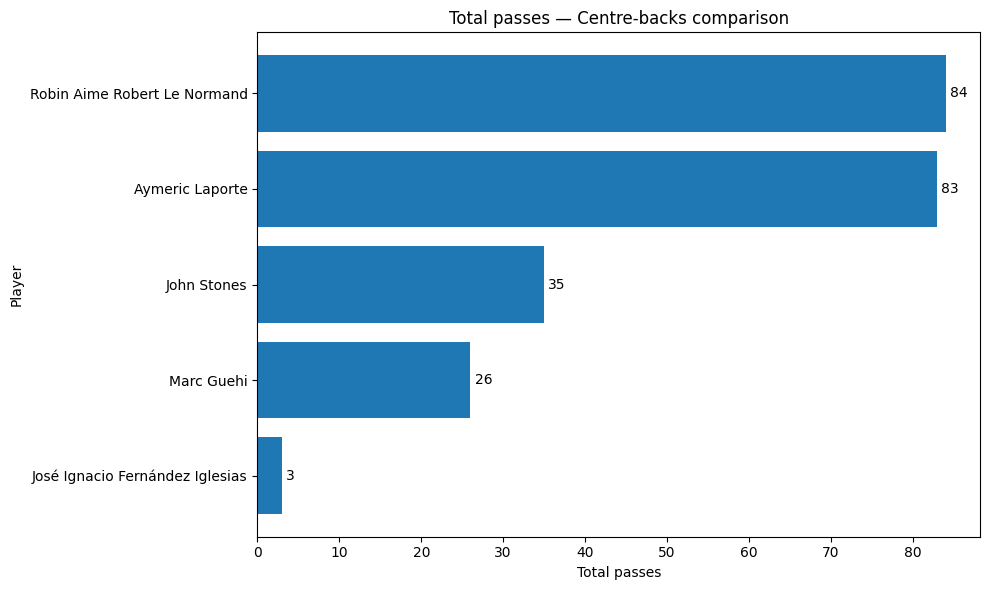

In [17]:
plot_df = comparison_table_display.sort_values(
    by="total_passes",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["player"],
    plot_df["total_passes"]
)

ax.set_title("Total passes — Centre-backs comparison")
ax.set_xlabel("Total passes")
ax.set_ylabel("Player")

for index, value in enumerate(plot_df["total_passes"]):
    ax.text(
        value + 0.5,
        index,
        str(value),
        va="center"
    )

plt.tight_layout()
plt.show()

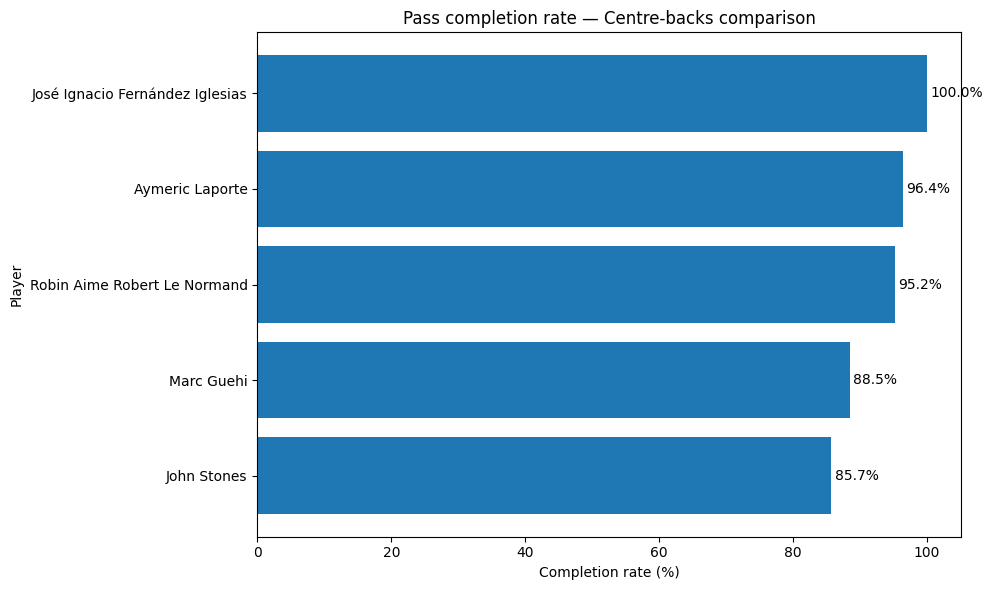

In [18]:
plot_df = comparison_table_display.sort_values(
    by="completion_rate_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["player"],
    plot_df["completion_rate_pct"]
)

ax.set_title("Pass completion rate — Centre-backs comparison")
ax.set_xlabel("Completion rate (%)")
ax.set_ylabel("Player")

for index, value in enumerate(plot_df["completion_rate_pct"]):
    ax.text(
        value + 0.5,
        index,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

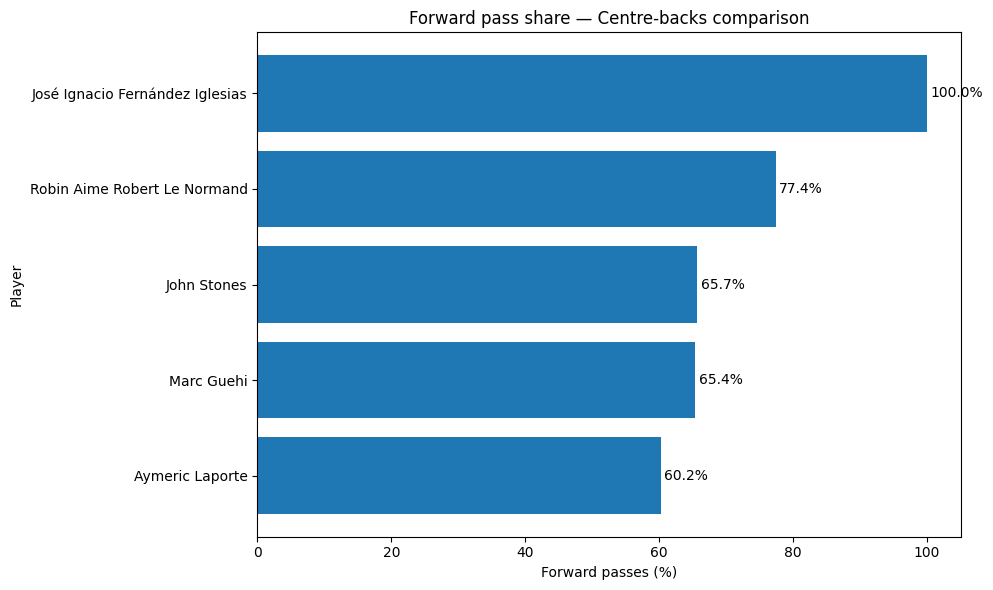

In [19]:
plot_df = comparison_table_display.sort_values(
    by="forward_pass_share_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["player"],
    plot_df["forward_pass_share_pct"]
)

ax.set_title("Forward pass share — Centre-backs comparison")
ax.set_xlabel("Forward passes (%)")
ax.set_ylabel("Player")

for index, value in enumerate(plot_df["forward_pass_share_pct"]):
    ax.text(
        value + 0.5,
        index,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

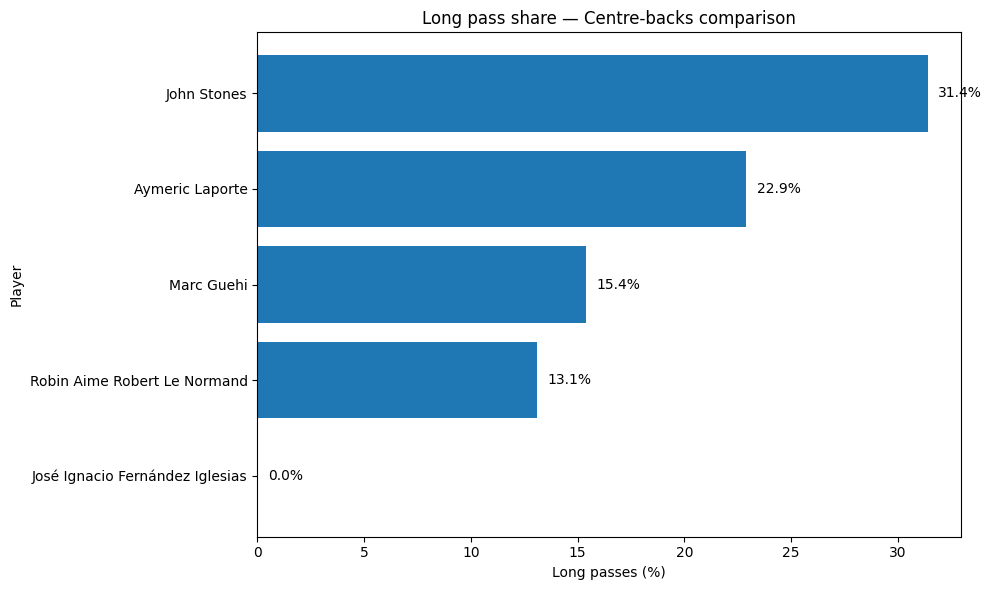

In [20]:
plot_df = comparison_table_display.sort_values(
    by="long_pass_share_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["player"],
    plot_df["long_pass_share_pct"]
)

ax.set_title("Long pass share — Centre-backs comparison")
ax.set_xlabel("Long passes (%)")
ax.set_ylabel("Player")

for index, value in enumerate(plot_df["long_pass_share_pct"]):
    ax.text(
        value + 0.5,
        index,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

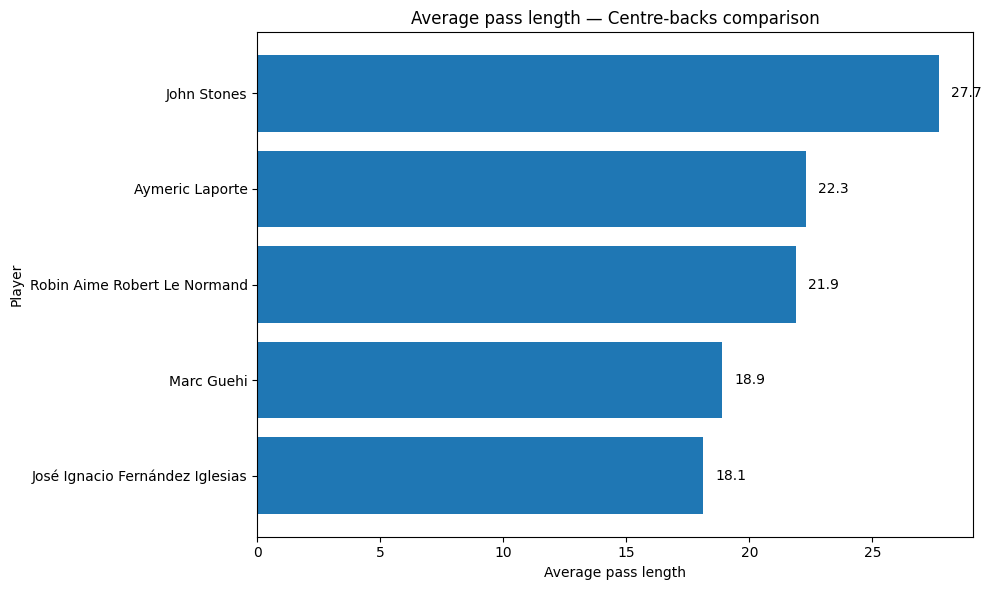

In [21]:
plot_df = comparison_table_display.sort_values(
    by="average_pass_length",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["player"],
    plot_df["average_pass_length"]
)

ax.set_title("Average pass length — Centre-backs comparison")
ax.set_xlabel("Average pass length")
ax.set_ylabel("Player")

for index, value in enumerate(plot_df["average_pass_length"]):
    ax.text(
        value + 0.5,
        index,
        f"{value:.1f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [22]:
most_passes_player = comparison_table_display.sort_values(
    by="total_passes",
    ascending=False
).iloc[0]

best_completion_player = comparison_table_display.sort_values(
    by="completion_rate_pct",
    ascending=False
).iloc[0]

most_forward_player = comparison_table_display.sort_values(
    by="forward_pass_share_pct",
    ascending=False
).iloc[0]

most_long_pass_player = comparison_table_display.sort_values(
    by="long_pass_share_pct",
    ascending=False
).iloc[0]

longest_average_pass_player = comparison_table_display.sort_values(
    by="average_pass_length",
    ascending=False
).iloc[0]

In [23]:
OUTPUT_CHARTS_DIR = Path("../outputs/comparison_charts")
OUTPUT_CHARTS_DIR.mkdir(parents=True, exist_ok=True)

In [24]:
fig.savefig(
    OUTPUT_CHARTS_DIR / "total_passes_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

In [30]:
from pathlib import Path

OUTPUT_CHARTS_DIR = Path("../outputs/comparison_charts")
OUTPUT_CHARTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CHARTS_DIR

WindowsPath('../outputs/comparison_charts')

In [32]:
%who

COMPARISON_FILE	 OUTPUT_CHARTS_DIR	 OUTPUT_TABLE	 Path	 ax	 best_completion_player	 comparison_df	 comparison_table	 comparison_table_display	 
fig	 index	 longest_average_pass_player	 most_forward_player	 most_long_pass_player	 most_passes_player	 pd	 plot_df	 plt	 
value	 


In [33]:
MIN_PASSES = 20

comparison_table_filtered = comparison_table_display[
    comparison_table_display["total_passes"] >= MIN_PASSES
].copy()

comparison_table_filtered

,player,team,position,total_passes,completed_passes,incomplete_passes,completion_rate_pct,forward_passes,forward_pass_share_pct,long_passes,long_pass_share_pct,average_pass_length
4,Robin Aime Robert Le Normand,Spain,Right Center Back,84,80,4,95.2,65,77.4,11,13.1,21.9
2,Aymeric Laporte,Spain,Left Center Back,83,80,3,96.4,50,60.2,19,22.9,22.3
0,John Stones,England,Right Center Back,35,30,5,85.7,23,65.7,11,31.4,27.7
1,Marc Guehi,England,Left Center Back,26,23,3,88.5,17,65.4,4,15.4,18.9


In [34]:
from pathlib import Path
import pandas as pd

COMPARISON_FILE = Path("../outputs/metrics/euro_2024_final_centre_backs_comparison.csv")

comparison_df = pd.read_csv(COMPARISON_FILE)

comparison_df["completion_rate_pct"] = comparison_df["completion_rate"] * 100
comparison_df["forward_pass_share_pct"] = comparison_df["forward_pass_share"] * 100
comparison_df["long_pass_share_pct"] = comparison_df["long_pass_share"] * 100

comparison_table = comparison_df[
    [
        "player",
        "team",
        "position",
        "total_passes",
        "completed_passes",
        "incomplete_passes",
        "completion_rate_pct",
        "forward_passes",
        "forward_pass_share_pct",
        "long_passes",
        "long_pass_share_pct",
        "average_pass_length",
    ]
].copy()

comparison_table_display = comparison_table.copy()

comparison_table_display["completion_rate_pct"] = comparison_table_display["completion_rate_pct"].round(1)
comparison_table_display["forward_pass_share_pct"] = comparison_table_display["forward_pass_share_pct"].round(1)
comparison_table_display["long_pass_share_pct"] = comparison_table_display["long_pass_share_pct"].round(1)
comparison_table_display["average_pass_length"] = comparison_table_display["average_pass_length"].round(1)

MIN_PASSES = 20

comparison_table_filtered = comparison_table_display[
    comparison_table_display["total_passes"] >= MIN_PASSES
].copy()

comparison_table_filtered

,player,team,position,total_passes,completed_passes,incomplete_passes,completion_rate_pct,forward_passes,forward_pass_share_pct,long_passes,long_pass_share_pct,average_pass_length
0,John Stones,England,Right Center Back,35,30,5,85.7,23,65.7,11,31.4,27.7
1,Marc Guehi,England,Left Center Back,26,23,3,88.5,17,65.4,4,15.4,18.9
2,Aymeric Laporte,Spain,Left Center Back,83,80,3,96.4,50,60.2,19,22.9,22.3
4,Robin Aime Robert Le Normand,Spain,Right Center Back,84,80,4,95.2,65,77.4,11,13.1,21.9


In [35]:
plot_df = comparison_table_filtered.sort_values(
    by="total_passes",
    ascending=True
)

In [1]:
from pathlib import Path

OUTPUT_CHARTS_DIR = Path("../outputs/comparison_charts")
OUTPUT_CHARTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CHARTS_DIR

WindowsPath('../outputs/comparison_charts')

In [4]:
from pathlib import Path
import pandas as pd

COMPARISON_FILE = Path("../outputs/metrics/euro_2024_final_centre_backs_comparison.csv")

comparison_df = pd.read_csv(COMPARISON_FILE)

comparison_df["completion_rate_pct"] = comparison_df["completion_rate"] * 100
comparison_df["forward_pass_share_pct"] = comparison_df["forward_pass_share"] * 100
comparison_df["long_pass_share_pct"] = comparison_df["long_pass_share"] * 100

comparison_table = comparison_df[
    [
        "player",
        "team",
        "position",
        "total_passes",
        "completed_passes",
        "incomplete_passes",
        "completion_rate_pct",
        "forward_passes",
        "forward_pass_share_pct",
        "long_passes",
        "long_pass_share_pct",
        "average_pass_length",
    ]
].copy()

comparison_table_display = comparison_table.copy()

comparison_table_display["completion_rate_pct"] = comparison_table_display["completion_rate_pct"].round(1)
comparison_table_display["forward_pass_share_pct"] = comparison_table_display["forward_pass_share_pct"].round(1)
comparison_table_display["long_pass_share_pct"] = comparison_table_display["long_pass_share_pct"].round(1)
comparison_table_display["average_pass_length"] = comparison_table_display["average_pass_length"].round(1)

MIN_PASSES = 20

comparison_table_filtered = comparison_table_display[
    comparison_table_display["total_passes"] >= MIN_PASSES
].copy()

comparison_table_filtered

,player,team,position,total_passes,completed_passes,incomplete_passes,completion_rate_pct,forward_passes,forward_pass_share_pct,long_passes,long_pass_share_pct,average_pass_length
0,John Stones,England,Right Center Back,35,30,5,85.7,23,65.7,11,31.4,27.7
1,Marc Guehi,England,Left Center Back,26,23,3,88.5,17,65.4,4,15.4,18.9
2,Aymeric Laporte,Spain,Left Center Back,83,80,3,96.4,50,60.2,19,22.9,22.3
4,Robin Aime Robert Le Normand,Spain,Right Center Back,84,80,4,95.2,65,77.4,11,13.1,21.9


In [5]:
plot_df = comparison_table_filtered.sort_values(
    by="total_passes",
    ascending=True
)

In [6]:
from pathlib import Path

OUTPUT_CHARTS_DIR = Path("../outputs/comparison_charts")
OUTPUT_CHARTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CHARTS_DIR

WindowsPath('../outputs/comparison_charts')

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [9]:
OUTPUT_CHARTS_DIR = Path("../outputs/comparison_charts")
OUTPUT_CHARTS_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_CHARTS_DIR = Path("../outputs/comparison_charts")
OUTPUT_CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("Imports and output directory OK")

Imports and output directory OK


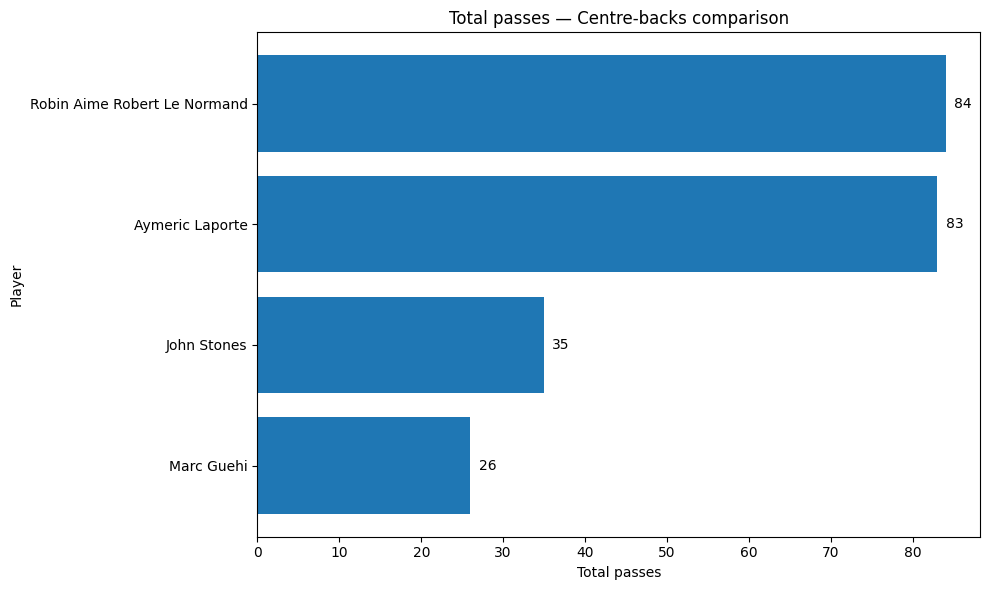

In [11]:
plot_df = comparison_table_filtered.sort_values(
    by="total_passes",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["player"],
    plot_df["total_passes"]
)

ax.set_title("Total passes — Centre-backs comparison")
ax.set_xlabel("Total passes")
ax.set_ylabel("Player")

for index, value in enumerate(plot_df["total_passes"]):
    ax.text(
        value + 1,
        index,
        str(value),
        va="center"
    )

plt.tight_layout()

fig.savefig(
    OUTPUT_CHARTS_DIR / "total_passes_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

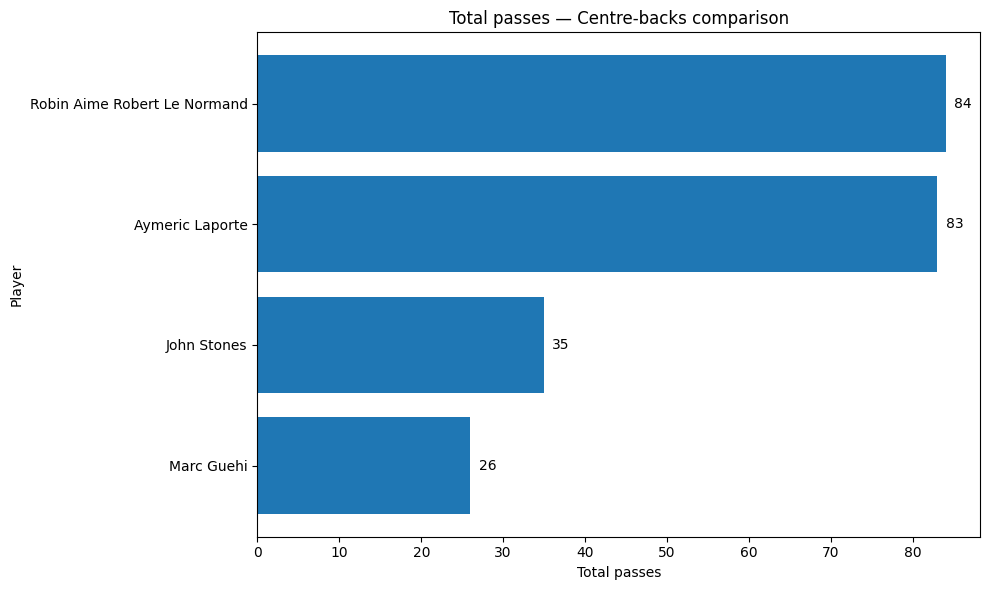

In [12]:
plot_df = comparison_table_filtered.sort_values(
    by="total_passes",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["player"],
    plot_df["total_passes"]
)

ax.set_title("Total passes — Centre-backs comparison")
ax.set_xlabel("Total passes")
ax.set_ylabel("Player")

for index, value in enumerate(plot_df["total_passes"]):
    ax.text(
        value + 1,
        index,
        str(value),
        va="center"
    )

plt.tight_layout()

fig.savefig(
    OUTPUT_CHARTS_DIR / "total_passes_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

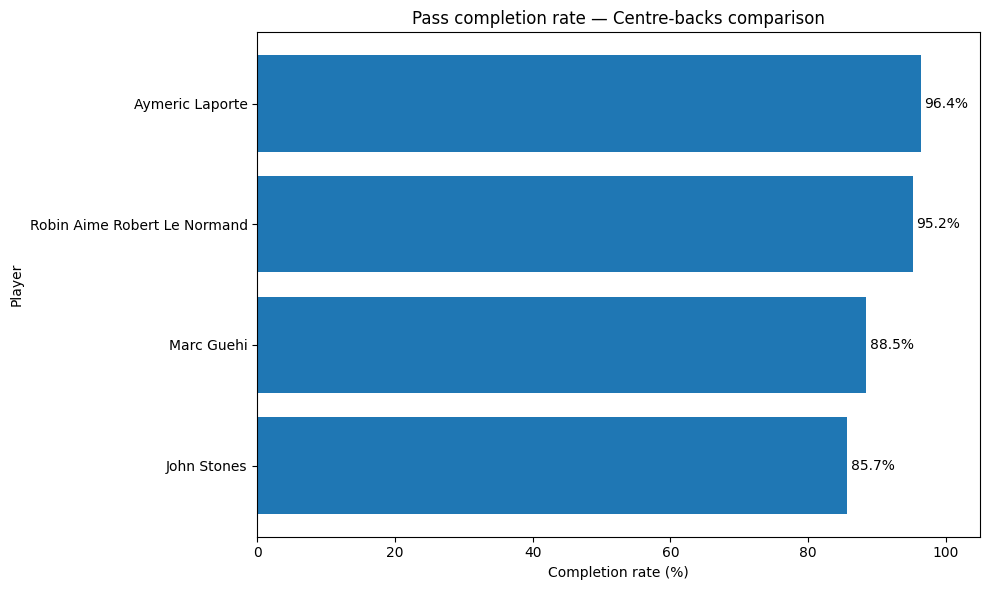

In [13]:
plot_df = comparison_table_filtered.sort_values(
    by="completion_rate_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["player"],
    plot_df["completion_rate_pct"]
)

ax.set_title("Pass completion rate — Centre-backs comparison")
ax.set_xlabel("Completion rate (%)")
ax.set_ylabel("Player")

for index, value in enumerate(plot_df["completion_rate_pct"]):
    ax.text(
        value + 0.5,
        index,
        f"{value:.1f}%",
        va="center"
    )

ax.set_xlim(0, 105)

plt.tight_layout()

fig.savefig(
    OUTPUT_CHARTS_DIR / "completion_rate_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

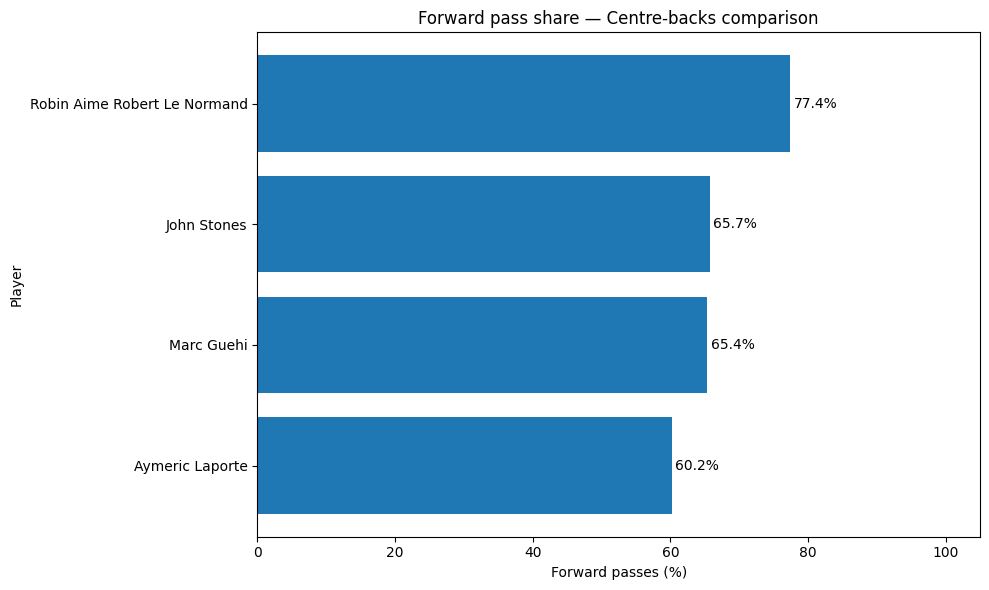

In [14]:
plot_df = comparison_table_filtered.sort_values(
    by="forward_pass_share_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["player"],
    plot_df["forward_pass_share_pct"]
)

ax.set_title("Forward pass share — Centre-backs comparison")
ax.set_xlabel("Forward passes (%)")
ax.set_ylabel("Player")

for index, value in enumerate(plot_df["forward_pass_share_pct"]):
    ax.text(
        value + 0.5,
        index,
        f"{value:.1f}%",
        va="center"
    )

ax.set_xlim(0, 105)

plt.tight_layout()

fig.savefig(
    OUTPUT_CHARTS_DIR / "forward_pass_share_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

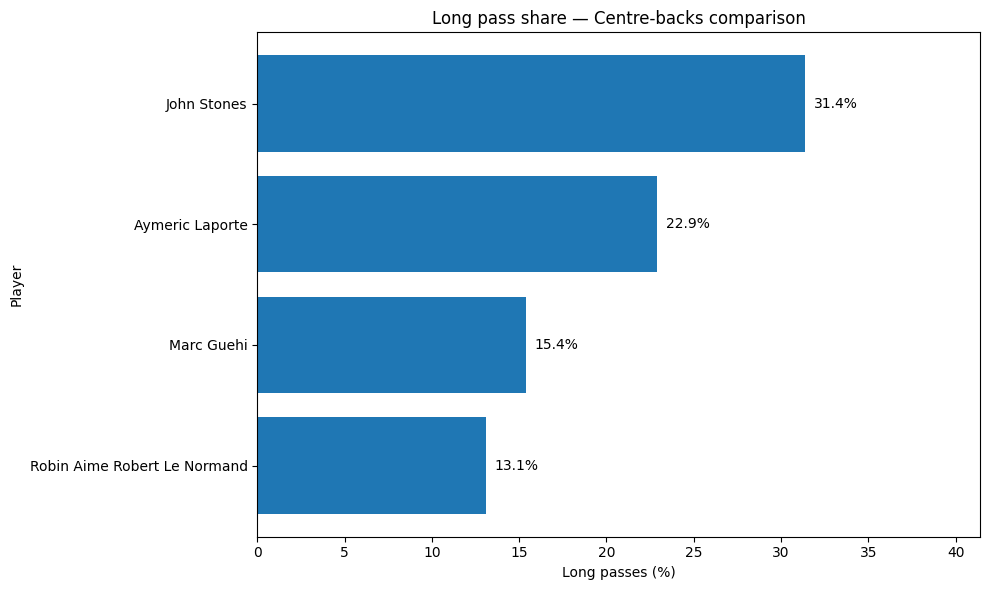

In [15]:
plot_df = comparison_table_filtered.sort_values(
    by="long_pass_share_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["player"],
    plot_df["long_pass_share_pct"]
)

ax.set_title("Long pass share — Centre-backs comparison")
ax.set_xlabel("Long passes (%)")
ax.set_ylabel("Player")

for index, value in enumerate(plot_df["long_pass_share_pct"]):
    ax.text(
        value + 0.5,
        index,
        f"{value:.1f}%",
        va="center"
    )

ax.set_xlim(0, max(plot_df["long_pass_share_pct"]) + 10)

plt.tight_layout()

fig.savefig(
    OUTPUT_CHARTS_DIR / "long_pass_share_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

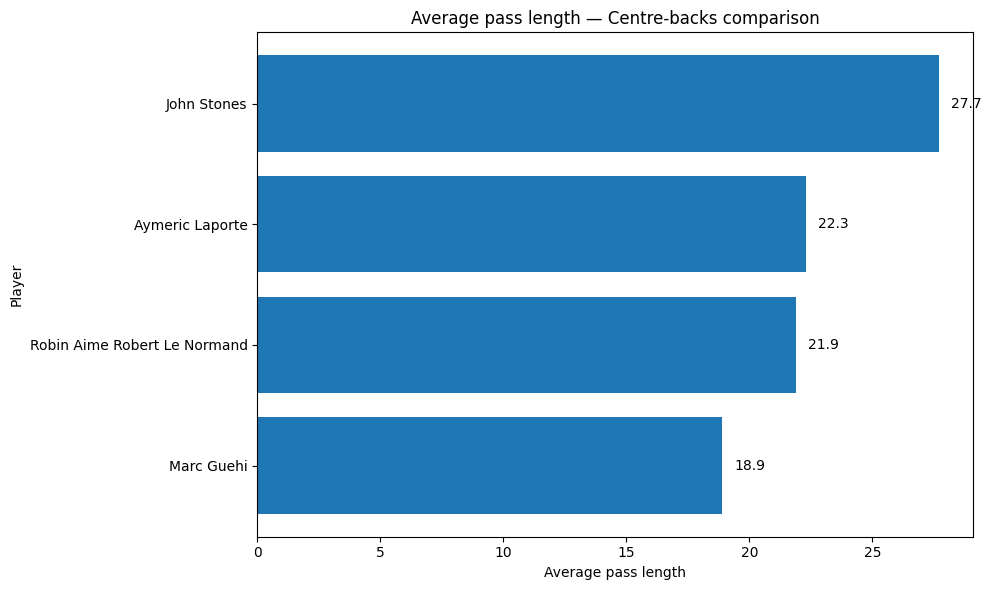

In [16]:
plot_df = comparison_table_filtered.sort_values(
    by="average_pass_length",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["player"],
    plot_df["average_pass_length"]
)

ax.set_title("Average pass length — Centre-backs comparison")
ax.set_xlabel("Average pass length")
ax.set_ylabel("Player")

for index, value in enumerate(plot_df["average_pass_length"]):
    ax.text(
        value + 0.5,
        index,
        f"{value:.1f}",
        va="center"
    )

plt.tight_layout()

fig.savefig(
    OUTPUT_CHARTS_DIR / "average_pass_length_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
list(OUTPUT_CHARTS_DIR.glob("*.png"))

[WindowsPath('../outputs/comparison_charts/average_pass_length_comparison.png'),
 WindowsPath('../outputs/comparison_charts/completion_rate_comparison.png'),
 WindowsPath('../outputs/comparison_charts/forward_pass_share_comparison.png'),
 WindowsPath('../outputs/comparison_charts/long_pass_share_comparison.png'),
 WindowsPath('../outputs/comparison_charts/total_passes_comparison.png')]

In [18]:
most_passes_player = comparison_table_filtered.sort_values(
    by="total_passes",
    ascending=False
).iloc[0]

best_completion_player = comparison_table_filtered.sort_values(
    by="completion_rate_pct",
    ascending=False
).iloc[0]

most_forward_player = comparison_table_filtered.sort_values(
    by="forward_pass_share_pct",
    ascending=False
).iloc[0]

most_long_pass_player = comparison_table_filtered.sort_values(
    by="long_pass_share_pct",
    ascending=False
).iloc[0]

longest_average_pass_player = comparison_table_filtered.sort_values(
    by="average_pass_length",
    ascending=False
).iloc[0]

In [19]:
print("Automatic analysis summary")
print("--------------------------")
print(
    f"Most involved player in possession: "
    f"{most_passes_player['player']} "
    f"({most_passes_player['total_passes']} passes)"
)

print(
    f"Best pass completion rate: "
    f"{best_completion_player['player']} "
    f"({best_completion_player['completion_rate_pct']:.1f}%)"
)

print(
    f"Highest forward pass share: "
    f"{most_forward_player['player']} "
    f"({most_forward_player['forward_pass_share_pct']:.1f}%)"
)

print(
    f"Highest long pass share: "
    f"{most_long_pass_player['player']} "
    f"({most_long_pass_player['long_pass_share_pct']:.1f}%)"
)

print(
    f"Longest average pass length: "
    f"{longest_average_pass_player['player']} "
    f"({longest_average_pass_player['average_pass_length']:.1f})"
)

Automatic analysis summary
--------------------------
Most involved player in possession: Robin Aime Robert Le Normand (84 passes)
Best pass completion rate: Aymeric Laporte (96.4%)
Highest forward pass share: Robin Aime Robert Le Normand (77.4%)
Highest long pass share: John Stones (31.4%)
Longest average pass length: John Stones (27.7)


In [20]:
profile_summary = pd.DataFrame(
    [
        {
            "insight": "Most involved in possession",
            "player": most_passes_player["player"],
            "team": most_passes_player["team"],
            "value": most_passes_player["total_passes"],
            "metric": "total_passes",
        },
        {
            "insight": "Best pass completion rate",
            "player": best_completion_player["player"],
            "team": best_completion_player["team"],
            "value": round(best_completion_player["completion_rate_pct"], 1),
            "metric": "completion_rate_pct",
        },
        {
            "insight": "Highest forward pass share",
            "player": most_forward_player["player"],
            "team": most_forward_player["team"],
            "value": round(most_forward_player["forward_pass_share_pct"], 1),
            "metric": "forward_pass_share_pct",
        },
        {
            "insight": "Highest long pass share",
            "player": most_long_pass_player["player"],
            "team": most_long_pass_player["team"],
            "value": round(most_long_pass_player["long_pass_share_pct"], 1),
            "metric": "long_pass_share_pct",
        },
        {
            "insight": "Longest average pass length",
            "player": longest_average_pass_player["player"],
            "team": longest_average_pass_player["team"],
            "value": round(longest_average_pass_player["average_pass_length"], 1),
            "metric": "average_pass_length",
        },
    ]
)

profile_summary

,insight,player,team,value,metric
0,Most involved in possession,Robin Aime Robert Le Normand,Spain,84.0,total_passes
1,Best pass completion rate,Aymeric Laporte,Spain,96.4,completion_rate_pct
2,Highest forward pass share,Robin Aime Robert Le Normand,Spain,77.4,forward_pass_share_pct
3,Highest long pass share,John Stones,England,31.4,long_pass_share_pct
4,Longest average pass length,John Stones,England,27.7,average_pass_length


In [21]:
PROFILE_SUMMARY_OUTPUT = Path("../outputs/metrics/euro_2024_final_centre_backs_profile_summary.csv")

profile_summary.to_csv(
    PROFILE_SUMMARY_OUTPUT,
    index=False,
    encoding="utf-8"
)

PROFILE_SUMMARY_OUTPUT.exists()

True

## First analytical reading

Based on the filtered comparison table, Robin Aime Robert Le Normand and Aymeric Laporte are the two most involved centre-backs in possession, with the highest pass volumes among the compared players.

Robin Le Normand appears as the most involved player in the build-up phase by total pass volume, while also showing a high share of forward passes.

Aymeric Laporte combines high pass volume with the best pass completion rate among the main centre-backs, suggesting a secure and reliable distribution profile.

John Stones shows the highest share of long passes and the longest average pass length, which may indicate a more direct passing profile in this match.

Marc Guéhi has a lower pass volume than the Spanish centre-backs, which reflects England’s lower involvement in possession during the match context.

In [22]:
list(Path("../outputs/metrics").glob("*.csv"))

[WindowsPath('../outputs/metrics/aymeric_laporte_metrics.csv'),
 WindowsPath('../outputs/metrics/euro_2024_final_centre_backs_comparison.csv'),
 WindowsPath('../outputs/metrics/euro_2024_final_centre_backs_comparison_clean.csv'),
 WindowsPath('../outputs/metrics/euro_2024_final_centre_backs_profile_summary.csv'),
 WindowsPath('../outputs/metrics/john_stones_metrics.csv'),
 WindowsPath('../outputs/metrics/jose_ignacio_fernandez_iglesias_metrics.csv'),
 WindowsPath('../outputs/metrics/marc_guehi_metrics.csv'),
 WindowsPath('../outputs/metrics/robin_aime_robert_le_normand_metrics.csv')]